**Install Libraries**

In [3]:
!pip -q install plotly

**Import Libraries**

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import plotly.express as px

import ast

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

**Load Dataset**

In [2]:
movies = pd.read_csv("/content/tmdb_5000_movies.csv")
credits = pd.read_csv("/content/tmdb_5000_credits.csv")

**Display Dataset**

In [5]:
movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [6]:
credits.head()

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


**Dataset Shape**

In [7]:
print("Movies Dataset Shape:", movies.shape)

print("Credits Dataset Shape:", credits.shape)

Movies Dataset Shape: (4803, 20)
Credits Dataset Shape: (4803, 4)


**Dataset Information**

In [8]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [9]:
credits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  4803 non-null   int64 
 1   title     4803 non-null   object
 2   cast      4803 non-null   object
 3   crew      4803 non-null   object
dtypes: int64(1), object(3)
memory usage: 150.2+ KB


****Missing Values****

In [10]:
movies.isnull().sum()

,0
budget,0
genres,0
homepage,3091
id,0
keywords,0
original_language,0
original_title,0
overview,3
popularity,0
production_companies,0


In [11]:
movies.duplicated().sum()

np.int64(0)

**Duplicate Values**

In [12]:
movies.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [13]:
# Merge movies and credits datasets
movies = movies.merge(credits, on='title')

print("Merged Dataset Shape:", movies.shape)
movies.head()

Merged Dataset Shape: (4809, 23)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [15]:
movies = movies[['movie_id',
                 'title',
                 'overview',
                 'genres',
                 'keywords',
                 'cast',
                 'crew',
                 'vote_average',
                 'vote_count',
                 'popularity',
                 'release_date',
                 'runtime',
                 'original_language']]

movies.head()

,movie_id,title,overview,genres,keywords,cast,crew,vote_average,vote_count,popularity,release_date,runtime,original_language
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",7.2,11800,150.437577,2009-12-10,162.0,en
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",6.9,4500,139.082615,2007-05-19,169.0,en
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",6.3,4466,107.376788,2015-10-26,148.0,en
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",7.6,9106,112.312950,2012-07-16,165.0,en
4,49529,John Carter,"John Carter is a war-weary, former military ca...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",6.1,2124,43.926995,2012-03-07,132.0,en


In [16]:
movies.isnull().sum()

,0
movie_id,0
title,0
overview,3
genres,0
keywords,0
cast,0
crew,0
vote_average,0
vote_count,0
popularity,0


In [17]:
movies.dropna(inplace=True)

print("Dataset Shape After Cleaning:", movies.shape)

Dataset Shape After Cleaning: (4805, 13)


In [18]:
movies.drop_duplicates(inplace=True)

print("Duplicate Movies:", movies.duplicated().sum())

Duplicate Movies: 0


In [19]:
import ast

def convert(text):
    L = []
    for i in ast.literal_eval(text):
        L.append(i['name'])
    return L

In [20]:
movies['genres'] = movies['genres'].apply(convert)

movies[['title', 'genres']].head()

,title,genres
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]"
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]"
2,Spectre,"[Action, Adventure, Crime]"
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]"
4,John Carter,"[Action, Adventure, Science Fiction]"


In [21]:
movies['keywords'] = movies['keywords'].apply(convert)

movies[['title', 'keywords']].head()

,title,keywords
0,Avatar,"[culture clash, future, space war, space colon..."
1,Pirates of the Caribbean: At World's End,"[ocean, drug abuse, exotic island, east india ..."
2,Spectre,"[spy, based on novel, secret agent, sequel, mi..."
3,The Dark Knight Rises,"[dc comics, crime fighter, terrorist, secret i..."
4,John Carter,"[based on novel, mars, medallion, space travel..."


In [22]:
def convert_cast(text):
    L = []

    counter = 0

    for i in ast.literal_eval(text):

        if counter != 3:
            L.append(i['name'])
            counter += 1

        else:
            break

    return L

In [23]:
movies['cast'] = movies['cast'].apply(convert_cast)

movies[['title', 'cast']].head()

,title,cast
0,Avatar,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]"
1,Pirates of the Caribbean: At World's End,"[Johnny Depp, Orlando Bloom, Keira Knightley]"
2,Spectre,"[Daniel Craig, Christoph Waltz, Léa Seydoux]"
3,The Dark Knight Rises,"[Christian Bale, Michael Caine, Gary Oldman]"
4,John Carter,"[Taylor Kitsch, Lynn Collins, Samantha Morton]"


In [24]:
def fetch_director(text):

    L = []

    for i in ast.literal_eval(text):

        if i['job'] == 'Director':

            L.append(i['name'])

    return L
    movies['crew'] = movies['crew'].apply(fetch_director)

movies[['title', 'crew']].head()

,title,crew
0,Avatar,"[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,Pirates of the Caribbean: At World's End,"[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,Spectre,"[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,The Dark Knight Rises,"[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,John Carter,"[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [25]:
movies['overview'] = movies['overview'].apply(lambda x: x.split())

movies[['title', 'overview']].head()

,title,overview
0,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d..."
2,Spectre,"[A, cryptic, message, from, Bond’s, past, send..."
3,The Dark Knight Rises,"[Following, the, death, of, District, Attorney..."
4,John Carter,"[John, Carter, is, a, war-weary,, former, mili..."


In [26]:
movies['genres'] = movies['genres'].apply(lambda x: [i.replace(" ", "") for i in x])

movies['keywords'] = movies['keywords'].apply(lambda x: [i.replace(" ", "") for i in x])

movies['cast'] = movies['cast'].apply(lambda x: [i.replace(" ", "") for i in x])

movies['crew'] = movies['crew'].apply(lambda x: [i.replace(" ", "") for i in x])

In [27]:
movies['tags'] = (movies['overview'] +
                  movies['genres'] +
                  movies['keywords'] +
                  movies['cast'] +
                  movies['crew'])

In [57]:
new_df = movies[['movie_id',
                 'title',
                 'tags',
                 'vote_average',
                 'vote_count',
                 'popularity',
                 'release_date',
                 'runtime',
                 'original_language']]

In [29]:
new_df['tags'] = new_df['tags'].apply(lambda x: " ".join(x))

new_df.head()

/tmp/ipykernel_1290/4247455151.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags'] = new_df['tags'].apply(lambda x: " ".join(x))


,movie_id,title,tags,vote_average,popularity,release_date,runtime,original_language
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...",7.2,150.437577,2009-12-10,162.0,en
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",6.9,139.082615,2007-05-19,169.0,en
2,206647,Spectre,A cryptic message from Bond’s past sends him o...,6.3,107.376788,2015-10-26,148.0,en
3,49026,The Dark Knight Rises,Following the death of District Attorney Harve...,7.6,112.312950,2012-07-16,165.0,en
4,49529,John Carter,"John Carter is a war-weary, former military ca...",6.1,43.926995,2012-03-07,132.0,en


In [30]:
new_df['tags'] = new_df['tags'].apply(lambda x: x.lower())

/tmp/ipykernel_1290/1380776331.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['tags'] = new_df['tags'].apply(lambda x: x.lower())


In [31]:
new_df.to_csv("cleaned_tmdb_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [33]:
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(new_df['tags'])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (4805, 33146)


In [34]:
cosine_sim = cosine_similarity(tfidf_matrix)

print(cosine_sim.shape)

(4805, 4805)


In [35]:
indices = pd.Series(new_df.index, index=new_df['title']).drop_duplicates()

In [36]:
def recommend(movie_name, top_n=10):

    if movie_name not in indices:
        print("❌ Movie not found.")
        return

    idx = indices[movie_name]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:top_n+1]

    movie_indices = [i[0] for i in similarity_scores]

    recommendations = new_df.iloc[movie_indices][[
        'title',
        'vote_average',
        'popularity',
        'release_date',
        'runtime',
        'original_language'
    ]]

    return recommendations

In [37]:
recommend("Avatar")

,title,vote_average,popularity,release_date,runtime,original_language
582,Battle: Los Angeles,5.5,49.199234,2011-03-08,116.0,en
3729,Falcon Rising,5.5,6.988357,2014-09-05,103.0,en
3607,Apollo 18,5.0,17.028252,2011-07-20,86.0,en
47,Star Trek Into Darkness,7.4,78.291018,2013-05-05,132.0,en
2405,Aliens,7.7,67.660940,1986-07-18,137.0,en
539,Titan A.E.,6.3,14.443810,2000-06-16,94.0,en
1202,Predators,6.0,47.649554,2010-07-03,107.0,en
1916,Lifeforce,6.2,12.183620,1985-06-20,116.0,en
942,The Book of Life,7.3,34.890999,2014-10-01,95.0,en
838,Alien³,6.2,45.856409,1992-05-22,114.0,en


In [39]:
movie_name = input("🎬 Enter Movie Name: ")

recommend(movie_name)

🎬 Enter Movie Name: The Dark Knight Rises


,title,vote_average,popularity,release_date,runtime,original_language
65,The Dark Knight,8.2,187.322927,2008-07-16,152.0,en
428,Batman Returns,6.6,59.113174,1992-06-19,126.0,en
299,Batman Forever,5.2,48.205606,1995-05-31,121.0,en
119,Batman Begins,7.5,115.040024,2005-06-10,140.0,en
1360,Batman,7.0,44.104469,1989-06-23,126.0,en
1361,Batman,7.0,44.104469,1989-06-23,126.0,en
3859,"Batman: The Dark Knight Returns, Part 2",7.9,25.891466,2013-01-18,78.0,en
210,Batman & Robin,4.2,50.073575,1997-06-20,125.0,en
9,Batman v Superman: Dawn of Justice,5.7,155.790452,2016-03-23,151.0,en
2509,Slow Burn,5.5,6.630856,2005-09-12,93.0,en


In [40]:
result = recommend(movie_name)

if result is not None:
    display(result.reset_index(drop=True))

,title,vote_average,popularity,release_date,runtime,original_language
0,The Dark Knight,8.2,187.322927,2008-07-16,152.0,en
1,Batman Returns,6.6,59.113174,1992-06-19,126.0,en
2,Batman Forever,5.2,48.205606,1995-05-31,121.0,en
3,Batman Begins,7.5,115.040024,2005-06-10,140.0,en
4,Batman,7.0,44.104469,1989-06-23,126.0,en
5,Batman,7.0,44.104469,1989-06-23,126.0,en
6,"Batman: The Dark Knight Returns, Part 2",7.9,25.891466,2013-01-18,78.0,en
7,Batman & Robin,4.2,50.073575,1997-06-20,125.0,en
8,Batman v Superman: Dawn of Justice,5.7,155.790452,2016-03-23,151.0,en
9,Slow Burn,5.5,6.630856,2005-09-12,93.0,en


In [41]:
def recommend(movie_name, top_n=10):

    if movie_name not in indices:
        print("Movie not found.")
        return

    idx = indices[movie_name]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )[1:top_n+1]

    recommendations = []

    for movie_idx, score in similarity_scores:

        recommendations.append({
            "Movie": new_df.iloc[movie_idx]["title"],
            "Similarity (%)": round(score * 100, 2),
            "Rating": new_df.iloc[movie_idx]["vote_average"],
            "Popularity": round(new_df.iloc[movie_idx]["popularity"], 2),
            "Language": new_df.iloc[movie_idx]["original_language"],
            "Release Date": new_df.iloc[movie_idx]["release_date"]
        })

    return pd.DataFrame(recommendations)

In [42]:
print("Number of Movies :", len(new_df))
print("Number of Languages :", new_df['original_language'].nunique())

print("\nLanguages:")
print(new_df['original_language'].unique())

Number of Movies : 4805
Number of Languages : 37

Languages:
['en' 'ja' 'fr' 'zh' 'es' 'de' 'hi' 'ru' 'ko' 'te' 'cn' 'it' 'nl' 'ta'
 'sv' 'th' 'da' 'xx' 'hu' 'cs' 'pt' 'is' 'tr' 'nb' 'af' 'pl' 'he' 'ar'
 'vi' 'ky' 'id' 'ro' 'fa' 'no' 'sl' 'ps' 'el']


In [43]:
language = new_df['original_language'].value_counts().head(10)

language

,count
original_language,
en,4508
fr,70
es,32
zh,27
de,26
hi,19
ja,16
it,13
ko,12


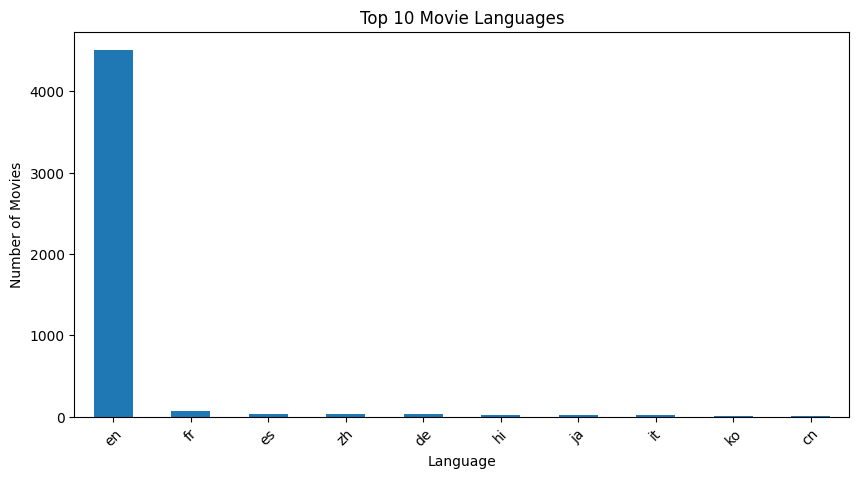

In [44]:
plt.figure(figsize=(10,5))

language.plot(kind='bar')

plt.title("Top 10 Movie Languages")
plt.xlabel("Language")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)

plt.show()

In [45]:
top_rated = new_df.sort_values(
    by="vote_average",
    ascending=False
).head(10)

top_rated[['title','vote_average']]

,title,vote_average
4252,Me You and Five Bucks,10.0
4050,"Dancer, Texas Pop. 81",10.0
3522,Stiff Upper Lips,10.0
4668,Little Big Top,10.0
3997,Sardaarji,9.5
2388,One Man's Hero,9.3
1883,The Shawshank Redemption,8.5
2973,There Goes My Baby,8.5
2798,The Prisoner of Zenda,8.4
3340,The Godfather,8.4


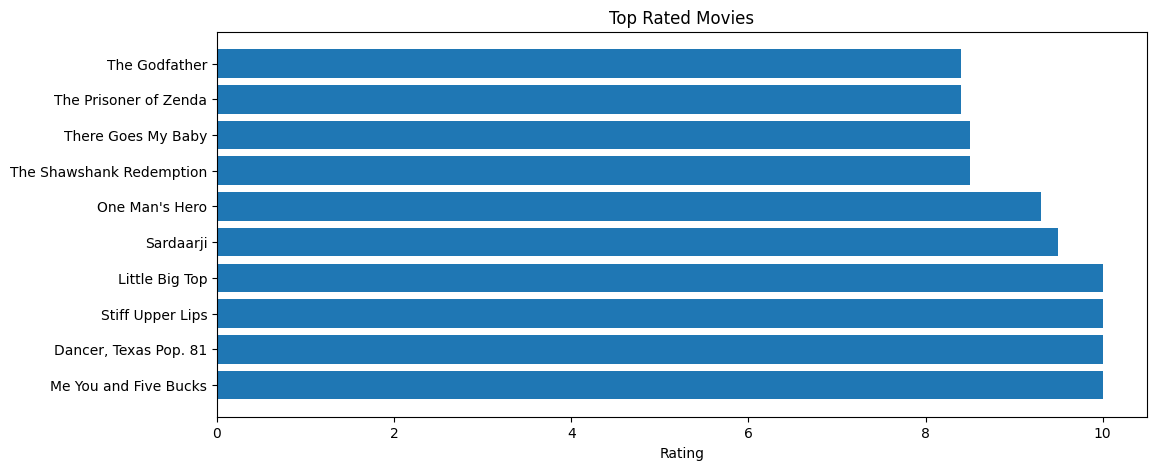

In [46]:
plt.figure(figsize=(12,5))

plt.barh(
    top_rated['title'],
    top_rated['vote_average']
)

plt.xlabel("Rating")
plt.title("Top Rated Movies")

plt.show()

In [47]:
popular = new_df.sort_values(
    by="popularity",
    ascending=False
).head(10)

popular[['title','popularity']]

,title,popularity
546,Minions,875.581305
95,Interstellar,724.247784
788,Deadpool,514.569956
94,Guardians of the Galaxy,481.098624
127,Mad Max: Fury Road,434.278564
28,Jurassic World,418.708552
199,Pirates of the Caribbean: The Curse of the Bla...,271.972889
82,Dawn of the Planet of the Apes,243.791743
200,The Hunger Games: Mockingjay - Part 1,206.227151
88,Big Hero 6,203.734590


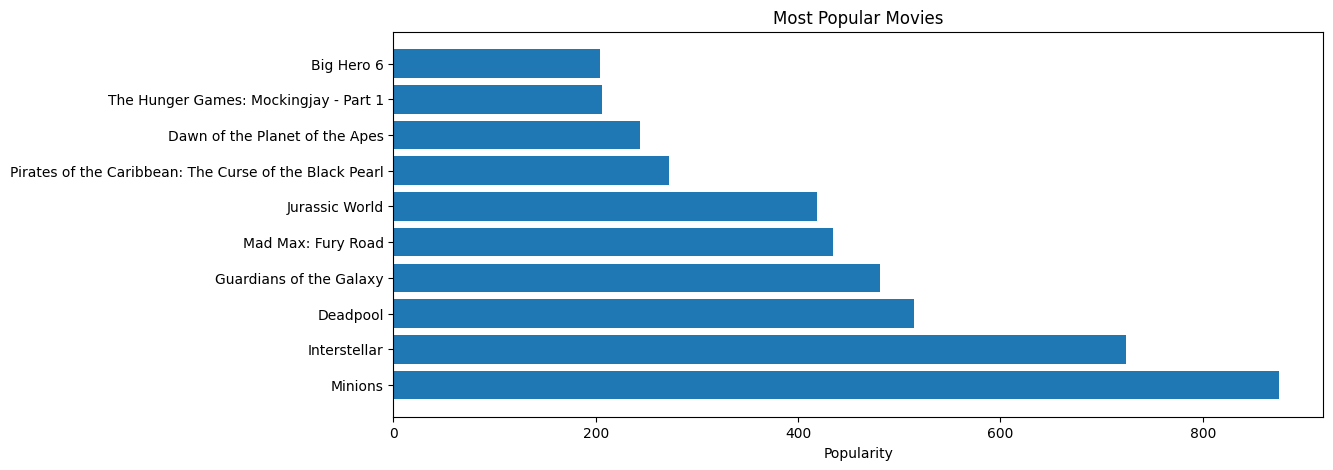

In [48]:
plt.figure(figsize=(12,5))

plt.barh(
    popular['title'],
    popular['popularity']
)

plt.xlabel("Popularity")

plt.title("Most Popular Movies")

plt.show()

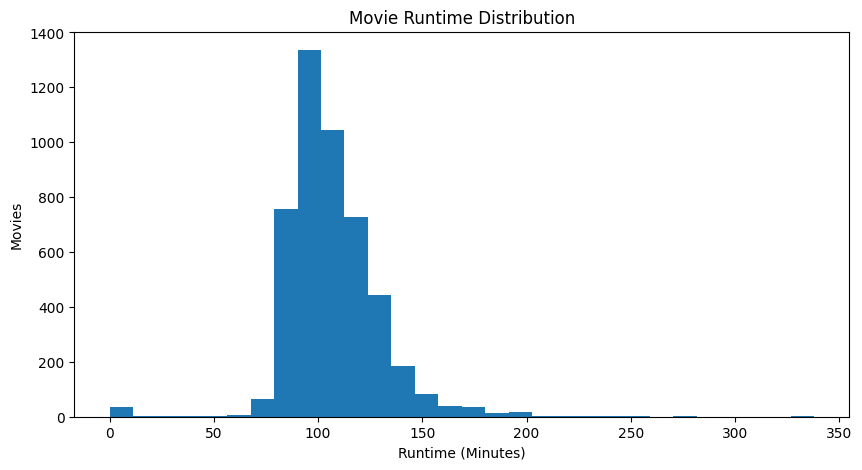

In [49]:
plt.figure(figsize=(10,5))

plt.hist(
    new_df['runtime'],
    bins=30
)

plt.xlabel("Runtime (Minutes)")

plt.ylabel("Movies")

plt.title("Movie Runtime Distribution")

plt.show()

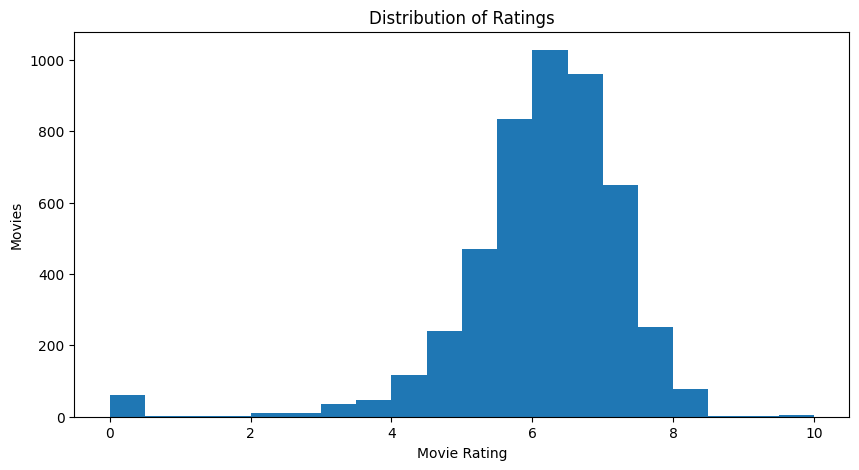

In [50]:
plt.figure(figsize=(10,5))

plt.hist(
    new_df['vote_average'],
    bins=20
)

plt.xlabel("Movie Rating")

plt.ylabel("Movies")

plt.title("Distribution of Ratings")

plt.show()

In [51]:
new_df['release_date'] = pd.to_datetime(
    new_df['release_date'],
    errors='coerce'
)

new_df['year'] = new_df['release_date'].dt.year

/tmp/ipykernel_1290/2057158944.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['release_date'] = pd.to_datetime(
/tmp/ipykernel_1290/2057158944.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['year'] = new_df['release_date'].dt.year


In [52]:
movies_year = new_df.groupby('year').size()

movies_year.tail()

,0
year,
2013,232
2014,237
2015,214
2016,104
2017,1


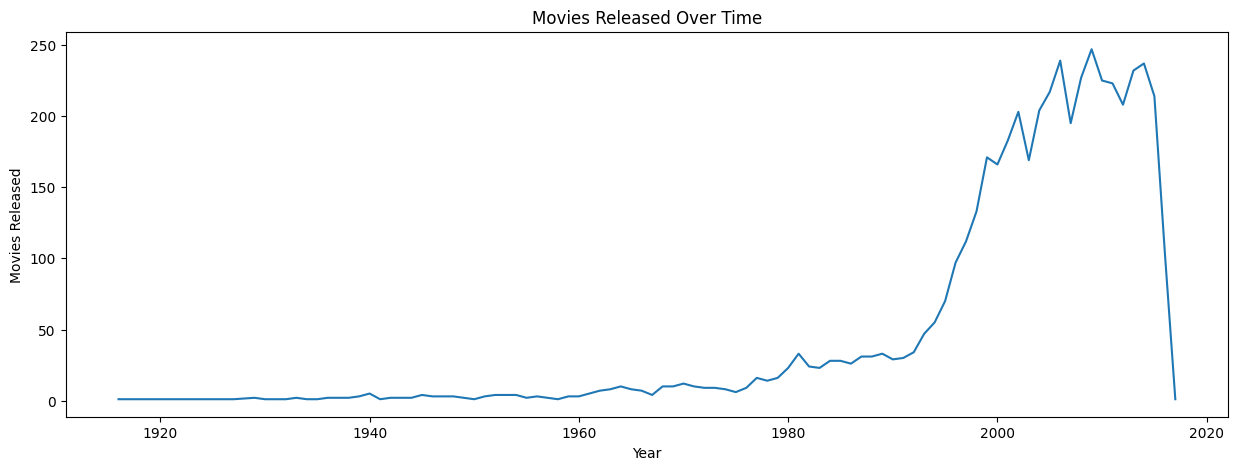

In [53]:
plt.figure(figsize=(15,5))

movies_year.plot()

plt.xlabel("Year")

plt.ylabel("Movies Released")

plt.title("Movies Released Over Time")

plt.show()

In [54]:
from collections import Counter

genre_counter = Counter()

for genres in movies['genres']:
    genre_counter.update(genres)

genre_df = pd.DataFrame(
    genre_counter.items(),
    columns=['Genre','Count']
)

genre_df = genre_df.sort_values(
    by='Count',
    ascending=False
)

genre_df.head(10)

,Genre,Count
5,Drama,2299
10,Comedy,1723
6,Thriller,1275
0,Action,1156
11,Romance,895
1,Adventure,792
4,Crime,697
3,ScienceFiction,538
12,Horror,520
8,Family,514


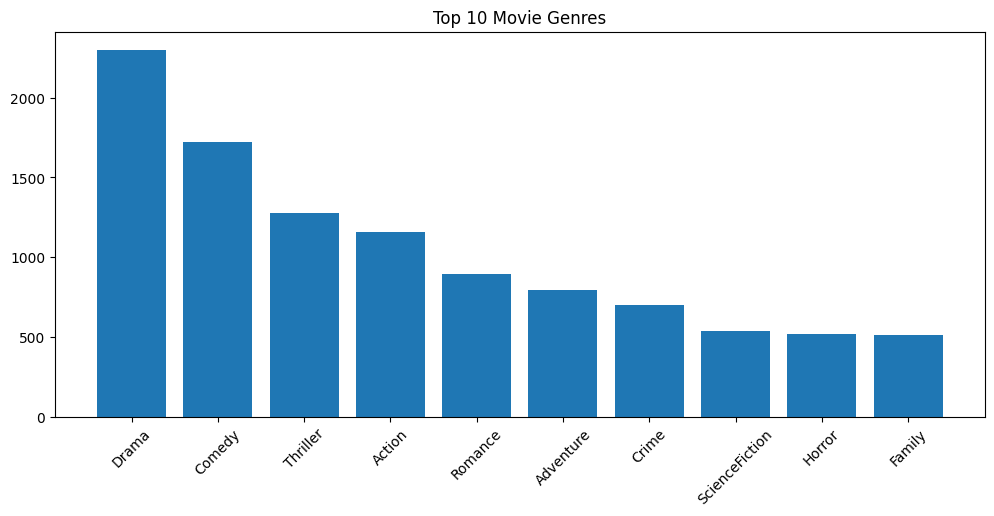

In [55]:
plt.figure(figsize=(12,5))

plt.bar(
    genre_df['Genre'][:10],
    genre_df['Count'][:10]
)

plt.xticks(rotation=45)

plt.title("Top 10 Movie Genres")

plt.show()

In [58]:
numeric = new_df[
    ['vote_average',
     'vote_count',
     'popularity',
     'runtime']
]

numeric.corr()

,vote_average,vote_count,popularity,runtime
vote_average,1.000000,0.313874,0.274420,0.372248
vote_count,0.313874,1.000000,0.778140,0.272246
popularity,0.274420,0.778140,1.000000,0.225539
runtime,0.372248,0.272246,0.225539,1.000000


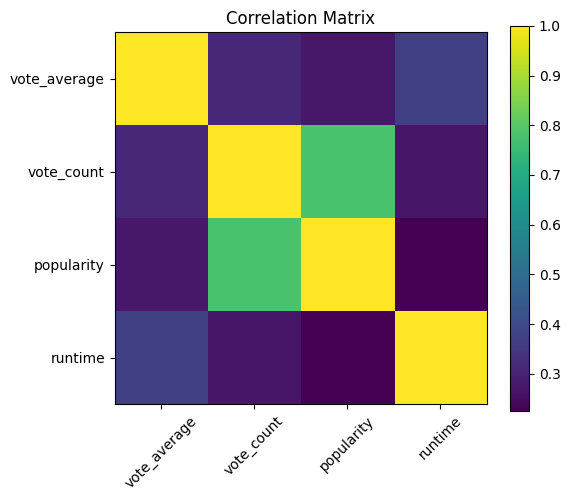

In [59]:
import matplotlib.pyplot as plt

corr = numeric.corr()

plt.figure(figsize=(6,5))

plt.imshow(corr)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar()

plt.title("Correlation Matrix")

plt.show()

## Insights

1. English movies dominate the dataset.

2. Drama and Comedy are the most common genres.

3. Most movies have ratings between 6 and 7.

4. The number of movies released increased significantly after 2000.

5. Highly popular movies are not always the highest rated.

6. Runtime generally falls between 90–150 minutes.

7. The recommendation engine uses textual similarity instead of ratings, helping users discover movies with similar themes.

In [80]:
indices = pd.Series(new_df.index, index=new_df['title']).drop_duplicates()

print("Movie index created successfully!")

Movie index created successfully!


In [81]:
def recommend(movie_name, top_n=10):

    movie_name = movie_name.strip()

    if movie_name not in indices:
        print(f"❌ '{movie_name}' not found in the dataset.")
        return

    idx = indices[movie_name]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )[1:top_n+1]

    recommendations = []

    for movie_idx, score in similarity_scores:

        recommendations.append({
            "Movie": new_df.iloc[movie_idx]["title"],
            "Rating": new_df.iloc[movie_idx]["vote_average"],
            "Popularity": round(new_df.iloc[movie_idx]["popularity"],2),
            "Release Date": new_df.iloc[movie_idx]["release_date"],
            "Language": new_df.iloc[movie_idx]["original_language"],
            "Similarity (%)": round(score*100,2)
        })

    return pd.DataFrame(recommendations)

In [82]:
recommend("Avatar")

,Movie,Rating,Popularity,Release Date,Language,Similarity (%)
0,Battle: Los Angeles,5.5,49.20,2011-03-08,en,12.90
1,Falcon Rising,5.5,6.99,2014-09-05,en,12.63
2,Apollo 18,5.0,17.03,2011-07-20,en,11.96
3,Star Trek Into Darkness,7.4,78.29,2013-05-05,en,11.89
4,Aliens,7.7,67.66,1986-07-18,en,11.65
5,Titan A.E.,6.3,14.44,2000-06-16,en,11.60
6,Predators,6.0,47.65,2010-07-03,en,10.73
7,Lifeforce,6.2,12.18,1985-06-20,en,10.02
8,The Book of Life,7.3,34.89,2014-10-01,en,9.74
9,Alien³,6.2,45.86,1992-05-22,en,9.69


In [83]:
recommend("The Dark Knight")

,Movie,Rating,Popularity,Release Date,Language,Similarity (%)
0,The Dark Knight Rises,7.6,112.31,2012-07-16,en,37.04
1,Batman Returns,6.6,59.11,1992-06-19,en,30.86
2,"Batman: The Dark Knight Returns, Part 2",7.9,25.89,2013-01-18,en,27.73
3,Batman Begins,7.5,115.04,2005-06-10,en,25.73
4,Batman Forever,5.2,48.21,1995-05-31,en,23.99
5,Batman,7.0,44.10,1989-06-23,en,22.94
6,Batman,7.0,44.10,1989-06-23,en,22.33
7,Batman v Superman: Dawn of Justice,5.7,155.79,2016-03-23,en,17.44
8,Batman & Robin,4.2,50.07,1997-06-20,en,16.73
9,Sherlock Holmes: A Game of Shadows,7.0,81.50,2011-11-22,en,9.86


In [84]:
recommend("Interstellar")

,Movie,Rating,Popularity,Release Date,Language,Similarity (%)
0,Contact,7.2,55.25,1997-07-11,en,11.98
1,Apollo 13,7.3,68.14,1995-06-30,en,11.49
2,Space Pirate Captain Harlock,6.5,14.73,2013-09-07,ja,11.07
3,The Martian,7.6,167.93,2015-09-30,en,10.98
4,Space Cowboys,6.3,15.77,2000-07-31,en,10.90
5,Armageddon,6.4,58.49,1998-07-01,en,10.11
6,Silent Running,6.3,11.10,1972-03-09,en,9.61
7,Gravity,7.3,110.15,2013-09-27,en,9.19
8,Deep Impact,5.9,34.07,1998-05-08,en,9.02
9,Mission to Mars,5.7,16.06,2000-03-10,en,8.87


In [87]:
movie = input("🎬 Enter Movie Name: ")

recommend(movie)

🎬 Enter Movie Name: Mission to Mars


,Movie,Rating,Popularity,Release Date,Language,Similarity (%)
0,Red Planet,5.4,13.80,2000-11-10,en,26.33
1,The Martian,7.6,167.93,2015-09-30,en,20.02
2,The Last Days on Mars,5.2,18.76,2013-08-11,en,18.71
3,Ghosts of Mars,4.8,13.15,2001-08-24,en,17.79
4,John Carter,6.1,43.93,2012-03-07,en,16.43
5,Mars Attacks!,6.1,44.09,1996-12-12,en,15.63
6,Pandorum,6.5,28.35,2009-09-08,en,13.71
7,Escape from Planet Earth,5.7,18.14,2013-02-14,en,13.64
8,Total Recall,7.1,43.13,1990-06-01,en,13.56
9,Capricorn One,6.4,11.10,1977-12-10,en,13.50
